In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from asyncssh import forward
from sklearn.model_selection import train_test_split
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import re
import copy
from sklearn.decomposition import PCA
import seaborn as sns

In [2]:
data = pd.read_csv('../dhi_medo_2c_30n/Dataset_medoids.csv')
data=data.drop(['top','seq'], axis=1)
cols=[c for c in data.columns if c != 'sredni_czas']
time_data=data['sredni_czas']
pca=PCA(n_components=128)
dih_PCA=pca.fit_transform(data[cols])
pca_cols = [f'PC{i+1}' for i in range(128)]
df_dih_PCA=pd.DataFrame(dih_PCA, columns=pca_cols, index=data.index)
data=pd.concat([df_dih_PCA, time_data], axis=1)
print(data.head(5))
varians_PCA=pca.explained_variance_ratio_
cum_varians_PCA=np.cumsum(varians_PCA)
print(f'Komponenty PCA wyjaśniają kolejno % wariancji: {varians_PCA}')
print(f'Cumulatywnie wyjaśniają: {cum_varians_PCA[-1]}')

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -1.663852 -0.039450  0.818656  0.730087  1.515799  0.674291  0.593883   
1 -1.705920 -0.033666  0.747576  0.253751  0.618163  0.498571  0.092681   
2 -1.851037 -0.012796  0.554108  0.164327  0.917758  0.683400  0.498099   
3 -1.761718  0.014094  0.603069  0.792039  1.123803  0.841325  0.216882   
4 -1.488965  0.073078  1.825265  0.149957  1.143413  0.988637  0.260981   

        PC8       PC9      PC10  ...     PC120     PC121     PC122     PC123  \
0 -2.358862  0.150413 -1.244442  ... -0.013808 -0.619365  0.066278  0.540365   
1 -2.325760  0.570132 -1.205298  ...  0.110555 -0.748224 -0.098733  0.152375   
2 -2.195665  0.114712 -1.162948  ... -0.194192 -0.421894 -0.232096  0.099115   
3 -2.665599  0.497266 -1.113819  ...  0.141630 -0.772753  0.213105  0.737689   
4 -2.376685  0.426761 -1.018626  ... -0.439604 -1.135303 -0.143708  0.239481   

      PC124     PC125     PC126     PC127     PC128    sredni_czas  

In [3]:
# podział na set nowy
train_fin, test_fin = train_test_split(data, test_size=0.05)

X_test=test_fin.drop(['sredni_czas'], axis=1)
Y_test=test_fin['sredni_czas']

train_set, val_set = train_test_split(train_fin, test_size=0.1)
X_train = train_set.drop(['sredni_czas'], axis=1)
X_val = val_set.drop(['sredni_czas'], axis=1)
Y_train = train_set['sredni_czas']
Y_val = val_set['sredni_czas']

# Tensory Y
Y_train_ten=torch.tensor(Y_train.to_numpy(), dtype=torch.float)
Y_val_ten=torch.tensor(Y_val.to_numpy(), dtype=torch.float)
Y_test_ten=torch.tensor(Y_test.to_numpy(), dtype=torch.float)

batch=32

# Tensory wejściowe kat --> time
X_ten_train_ang=torch.tensor(X_train.astype('float32').to_numpy(), dtype=torch.float)
X_ten_val_ang=torch.tensor(X_val.astype('float32').to_numpy(), dtype=torch.float)
X_ten_test_ang=torch.tensor(X_test.astype('float32').to_numpy(), dtype=torch.float)

# jednen dataset i dataloader dla połączonego modelu
train_ds_comb=TensorDataset( X_ten_train_ang, Y_train_ten)
train_loader_comb=DataLoader(train_ds_comb, batch_size=batch, shuffle=True)
val_ds_comb=TensorDataset(X_ten_val_ang, Y_val_ten)
val_loader_comb=DataLoader(val_ds_comb, batch_size=batch, shuffle=False)
#test_ds_comb=TensorDataset( X_ten_test_ang, Y_test)
#test_loader_comb=DataLoader(test_ds_comb, batch_size=batch, shuffle=False)

In [4]:
print(f'Długość train setu to: {len(train_set)}, długość test setu to: {len(test_fin)}, % test/train: {(len(test_fin)/len(train_fin))*100}')

Długość train setu to: 66407, długość test setu to: 3884, % test/train: 5.263871195077657


In [5]:
class GQuadTimeAng(nn.Module):
    def __init__(self):
        super(GQuadTimeAng, self).__init__()
        self.fc1=nn.Linear(128, 64)
        self.fc4=nn.Linear(64,32)
        self.fc6=nn.Linear(32,16)
        self.fc5=nn.Linear(16,1)


        # Activation and drop function
        self.re=nn.ReLU()
        self.drop=nn.Dropout(p=0.1)


    def forward(self, x):
        x=self.re(self.fc1(x))
        x=self.drop(x)
        x=self.re(self.fc4(x))
        x=self.drop(x)
        x=self.re(self.fc6(x))
        x=self.fc5(x)
        return x

model_fin = GQuadTimeAng()
optimizer= torch.optim.Adam(model_fin.parameters(), lr=0.001, weight_decay=0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)
critetion=nn.MSELoss()

epochs = 1000
best_val_loss = float('inf')
how_many=25
counter_dd=0
best_so_far=None
training_loss=[]
val_los=[]
epoch_data=[]

for epoch in range(epochs):
    model_fin.train()
    epoch_train_loss = 0
    epoch_data.append(epoch)
    for batch_X_a, batch_Y in train_loader_comb:
        optimizer.zero_grad()
        prediction = model_fin(batch_X_a)
        loss = critetion(prediction, batch_Y.float().unsqueeze(1)) # loss for normal model
        #loss = censored_mse_loss(prediction, batch_Y.float().unsqueeze(1), cap_value=1000000.0) # for log model
        loss.backward()
        optimizer.step()
        epoch_train_loss+=loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader_comb)
    training_loss.append(avg_train_loss)

    model_fin.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X_a, batch_Y in val_loader_comb:
            prediction = model_fin(batch_X_a)
            loss = critetion(prediction, batch_Y.float().unsqueeze(1)) # normal model
            #loss = censored_mse_loss(prediction, batch_Y.float().unsqueeze(1), cap_value=1000000.0) # for log model
            val_loss+=loss.item()


    avg_val_loss = val_loss / len(val_loader_comb)
    scheduler.step(avg_val_loss)
    val_los.append(avg_val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter_dd = 0
        best_so_far=copy.deepcopy(model_fin.state_dict())
    else:
        counter_dd += 1

    if epoch %5 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    if counter_dd >= how_many:
        print("Early Stopping")
        best_val_loss = np.sqrt(best_val_loss)
        #print(f'Średni błąd Validacji: {best_val_loss:.4f}')
        break

data_graph=pd.DataFrame({
    'Epoch': epoch_data,
    'Training Loss': training_loss,
    'Validation Loss': val_los
} )
model_fin.load_state_dict(best_so_far)

Epoch 000 | Train Loss: 108094875308.6397 | Val Loss: 50125988442.8745
Epoch 005 | Train Loss: 39754543798.5048 | Val Loss: 37724146116.1558
Epoch 010 | Train Loss: 30091758055.3372 | Val Loss: 28417213604.0173
Epoch 015 | Train Loss: 21868318845.2871 | Val Loss: 20312606555.9827
Epoch 020 | Train Loss: 15350928473.0328 | Val Loss: 13461569657.9048
Epoch 025 | Train Loss: 11949531211.0983 | Val Loss: 9531865264.2078
Epoch 030 | Train Loss: 10358821900.4547 | Val Loss: 7744494099.9481
Epoch 035 | Train Loss: 9598222266.3276 | Val Loss: 6709901037.7143
Epoch 040 | Train Loss: 9243283191.6763 | Val Loss: 6279786546.9784
Epoch 045 | Train Loss: 8810572536.6012 | Val Loss: 6001715355.7056
Epoch 050 | Train Loss: 8730400535.4297 | Val Loss: 5674814071.6883
Epoch 055 | Train Loss: 8550745372.6089 | Val Loss: 5482407010.0779
Epoch 060 | Train Loss: 8419407166.7052 | Val Loss: 5338398809.2121
Epoch 065 | Train Loss: 8325520179.1753 | Val Loss: 5132391080.4502
Epoch 070 | Train Loss: 8164936725.

<All keys matched successfully>

--- FINAL EXAM RESULTS ---
On average, the model is off by: 47877.61 time units
R-squared Score (Accuracy proxy): 0.95


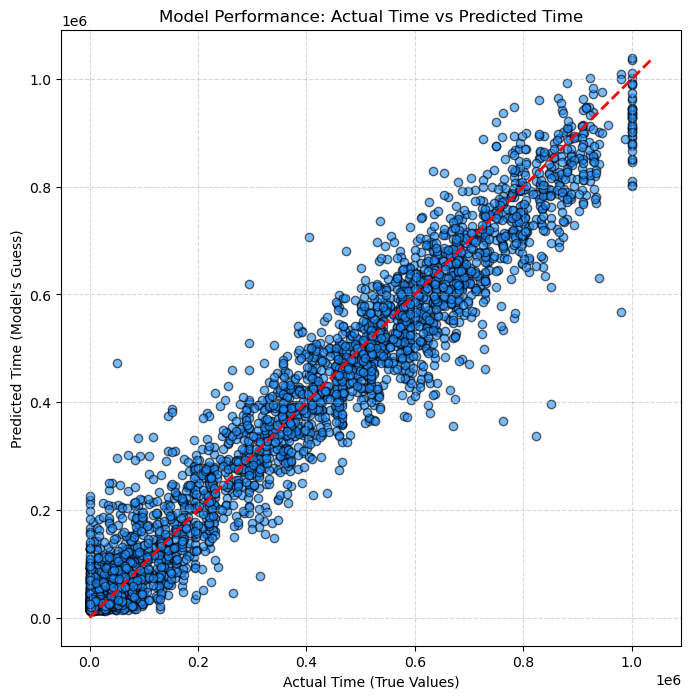

In [6]:
# 1. Put the model into evaluation mode (turns off training features)
model_fin.eval()

# 2. Make predictions on the completely unseen TEST data
with torch.no_grad():
    test_predictions = model_fin(X_ten_test_ang)

# 3. Convert PyTorch Tensors back to normal Numpy arrays
# (Matplotlib and Sklearn prefer normal arrays)
actuals = Y_test_ten.numpy()
preds = test_predictions.numpy()


#preds = (preds * Y_STD) + Y_MEAN
#actuals = (actuals * Y_STD) + Y_MEAN

#actuals = 1000000 * actuals
#preds = 1000000 * preds

# if using np.log1p()
#actuals=np.expm1(actuals)
#preds=np.expm1(preds)

# 4. Calculate "Human-Readable" Scores
# MAE (Mean Absolute Error): On average, how many units of time is the prediction wrong by?
mae = mean_absolute_error(actuals, preds)

# R2 Score: A percentage of how well the model fits the data (1.0 is perfect, 0.0 is terrible)
r2 = r2_score(actuals, preds)

print("--- FINAL EXAM RESULTS ---")
print(f"On average, the model is off by: {mae:.2f} time units")
print(f"R-squared Score (Accuracy proxy): {r2:.2f}")

# 5. Draw the "Actual vs. Predicted" Plot
plt.figure(figsize=(8, 8))
plt.scatter(actuals, preds, alpha=0.6, color='dodgerblue', edgecolors='k')

# Draw a red diagonal line. If the model is perfect, all blue dots will sit exactly on this red line.
min_val = min(actuals.min(), preds.min())
max_val = max(actuals.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

# Make the plot look nice
plt.title("Model Performance: Actual Time vs Predicted Time")
plt.xlabel("Actual Time (True Values)")
plt.ylabel("Predicted Time (Model's Guess)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

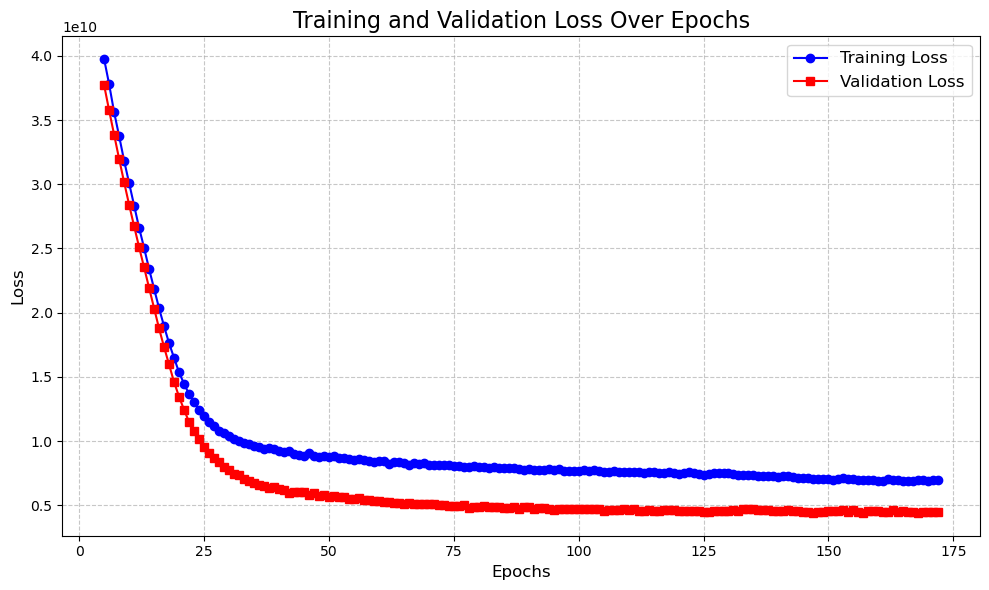

In [7]:
data_graph=data_graph.iloc[5:].reset_index(drop=True)

# Replace these with your actual lists of loss values
epochs = data_graph['Epoch'] # Assuming 15 epochs
train_loss = data_graph['Training Loss']
val_loss = data_graph['Validation Loss']

plt.figure(figsize=(10, 6))

# Plot the lines
plt.plot(epochs, train_loss, label='Training Loss', color='blue', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', color='red', marker='s')

# Add titles and labels
plt.title('Training and Validation Loss Over Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# Add a grid for easier reading
plt.grid(True, linestyle='--', alpha=0.7)

# Add the legend
plt.legend(loc='best', fontsize=12)

# Display the graph
plt.tight_layout()
plt.show()

In [12]:
print(f'Train len: {len(train_set)}, Validation len: {len(val_set)}, Tres len: {len(test_fin)} ')

Train len: 21653, Validation len: 2406, Tres len: 1267 


In [13]:
torch.save(model_fin.state_dict(), '../modele - wytrenowane/model_angPCAtime_good.pth')